# Insulin withdrawal and restoration

This simulation answers the question: if microglial insulin signaling is lost and
then fully restored, does plaque burden return to a healthy state?  (It does not.)

Two systems start with the same small plaque burden, placed just inside
the healthy basin. A transient period of impaired insulin signaling is enough to move the threshold below that burden, so the system leaves the healthy basin and grows. Restoring insulin signaling completely, and holding it at the intact value indefinitely, does not bring it back: the matched control clears its plaque, while the system that experienced the impairment remains permanently plaque-bearing.

This notebook produces Figure 7 of the manuscript. 

## Model

$$\frac{dS}{dt}=p_S-\delta_S S-k_{seed}S\frac{P^n}{K^n+P^n}+k_{rel}\frac{P}{K_{rel}+P},$$
$$\frac{dP}{dt}=k_{seed}S\frac{P^n}{K^n+P^n}-k_{clr}U(I,\Gamma)P,$$
$$\frac{d\Gamma}{dt}=k_S\frac{S}{K_S+S}+k_P\frac{P}{K_P+P}-\delta_\Gamma\Gamma,
\qquad U(I,\Gamma)=U_0\frac{I}{1+\lambda\Gamma}.$$

Parameters follow Table 1.

In [1]:
import os

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 12.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

os.makedirs("figures", exist_ok=True)

# Baseline parameters (Table 1). Named PAR rather than P so that the symbol P is
# reserved for plaque burden, as in the manuscript equations.
PAR = dict(pS=26424.0, dS=1.0, kseed=1e-2, K=4.0e5, n=2.0,
           krel=1e-3, Krel=4.0e5, kclr=1.44e-4, lam=0.5,
           kS=3e-3, kP=3e-4, KS=26424.0, KP=2.006191e6, dG=6e-3)

HPY = 24 * 365.25          # hours per year; the model runs in hours, plots in years
I_WT, I_IRKO = 1.0, 0.6    # intact and impaired microglial insulin signaling

def uM(x):
    """Convert a concentration in pM to uM for plotting."""
    return x / 1e6

In [2]:
def rhs(t, y, I_func, par):
    """Right-hand side of the three-variable model, with insulin signaling I(t)."""
    S, P, G = y
    P = max(P, 0.0)                    # guard the Hill term against small negative P
    Pn = P ** par["n"]
    H = Pn / (par["K"] ** par["n"] + Pn)
    U = I_func(t) / (1.0 + par["lam"] * G)
    dS = par["pS"] - par["dS"] * S - par["kseed"] * S * H + par["krel"] * P / (par["Krel"] + P)
    dP = par["kseed"] * S * H - par["kclr"] * U * P
    dG = par["kS"] * S / (par["KS"] + S) + par["kP"] * P / (par["KP"] + P) - par["dG"] * G
    return [dS, dP, dG]


def run(IC, I_signal, years, npts=4000, par=PAR):
    """Integrate a constant or time-varying insulin protocol. Returns t in years."""
    I_func = I_signal if callable(I_signal) else (lambda t: I_signal)
    t_eval = np.linspace(0.0, years * HPY, npts)
    sol = solve_ivp(rhs, [0.0, years * HPY], IC, args=(I_func, par), method="LSODA",
                    rtol=1e-9, atol=[1e-2, 1e0, 1e-10], t_eval=t_eval)
    return sol.t / HPY, sol.y[0], sol.y[1], sol.y[2]

## Calibration check

The two plateaus the simulation moves between, and the threshold separating each of them
from the plaque-free state. The threshold follows from $P^*_-P^*_+=K^2$ (Appendix C),
so it can be read off the high-plaque equilibrium without a separate continuation.

In [3]:
# Start high on the plaque branch so the integration settles onto the high-plaque
# equilibrium rather than the plaque-free one.
IC_HIGH = [26424.0, 5.0e6, 0.28]

P_wt = run(IC_HIGH, I_WT, 400)[2][-1]
P_irko = run(IC_HIGH, I_IRKO, 400)[2][-1]

thresh_wt = PAR["K"] ** 2 / P_wt
thresh_irko = PAR["K"] ** 2 / P_irko

print(f"high-plaque equilibrium, I = 1.0 : {uM(P_wt):.3f} uM")
print(f"high-plaque equilibrium, I = 0.6 : {uM(P_irko):.3f} uM")
print(f"fold change IRKO / WT            : {P_irko / P_wt:.3f}   (manuscript: 1.71)")
print(f"threshold at I = 1.0             : {thresh_wt:,.0f} pM")
print(f"threshold at I = 0.6             : {thresh_irko:,.0f} pM")

high-plaque equilibrium, I = 1.0 : 1.986 uM
high-plaque equilibrium, I = 0.6 : 3.406 uM
fold change IRKO / WT            : 1.715   (manuscript: 1.71)
threshold at I = 1.0             : 80,578 pM
threshold at I = 0.6             : 46,978 pM


## The simulation

Two systems are given **the same initial plaque burden**, $6\times10^{4}$ pM. That value
lies below the threshold under intact signaling ($\approx 8.1\times10^{4}$ pM) but above
the threshold under impaired signaling ($\approx 4.7\times10^{4}$ pM), so it sits in the
healthy basin of one system and the diseased basin of the other.

* **Control.** Insulin signaling intact throughout.
* **Transient impairment.** Insulin signaling reduced to $I=0.6$ for fifteen years, then
  restored fully to $I=1$ and held there.

The restoration is complete, not partial: $I$ returns to its maximum physiological value.

In [4]:
SEED = 6.0e4       # initial plaque burden, pM
T_BACK = 15.0      # years of impaired signaling before restoration
T_END = 60.0       # total simulated time, years

IC = [26424.0, SEED, 0.055]

def transient(t):
    """Impaired for T_BACK years, then fully restored."""
    return I_IRKO if t / HPY < T_BACK else I_WT

t_dis, _, P_dis, _ = run(IC, transient, T_END)
t_ok, _, P_ok, _ = run(IC, I_WT, T_END)

# The control decays to zero to within the integration tolerance, which can leave a
# final value a fraction of a pM below zero. Clamp it for reporting only.
P_ok_final = max(P_ok[-1], 0.0)

print(f"initial plaque             : {SEED:,.0f} pM")
print(f"  threshold at I = 1.0     : {thresh_wt:,.0f} pM   -> seed is below, would clear")
print(f"  threshold at I = 0.6     : {thresh_irko:,.0f} pM   -> seed is above, will grow")
print()
print(f"control, intact throughout : final {P_ok_final:.3e} pM  -> clears")
print(f"transient impairment       : final {uM(P_dis[-1]):.3f} uM -> high-plaque state")

initial plaque             : 60,000 pM
  threshold at I = 1.0     : 80,578 pM   -> seed is below, would clear
  threshold at I = 0.6     : 46,978 pM   -> seed is above, will grow

control, intact throughout : final 0.000e+00 pM  -> clears
transient impairment       : final 1.986 uM -> high-plaque state


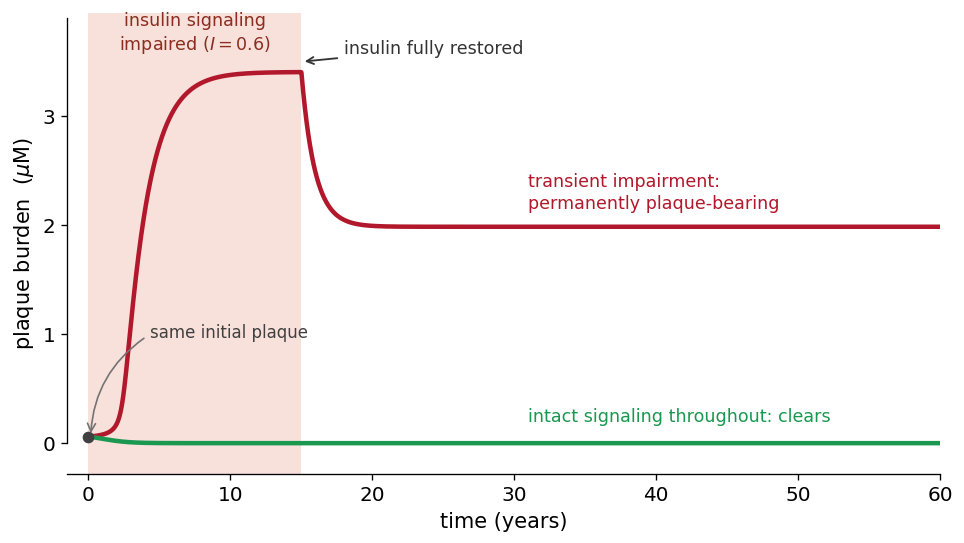

In [5]:
C_DIS, C_OK, C_BAND = "#b2182b", "#1a9850", "#f6d6cf"

fig, ax = plt.subplots(figsize=(8.2, 4.7))

# Shaded window marking the period of impaired signaling.
ax.axvspan(0, T_BACK, color=C_BAND, alpha=0.75, lw=0, zorder=0)
ax.text(T_BACK / 2, 3.76, "insulin signaling\nimpaired ($I=0.6$)", ha="center",
        va="center", fontsize=10.5, color="#8c2d20", linespacing=1.25)
ax.annotate("insulin fully restored", xy=(T_BACK, 3.50), xytext=(T_BACK + 3.0, 3.62),
            fontsize=10.5, color="#333333", va="center",
            arrowprops=dict(arrowstyle="->", color="#333333", lw=1.1))

ax.plot(t_dis, uM(P_dis), color=C_DIS, lw=2.7, zorder=3)
ax.plot(t_ok, uM(P_ok), color=C_OK, lw=2.7, zorder=3)
ax.text(31, 2.12, "transient impairment:\npermanently plaque-bearing",
        color=C_DIS, fontsize=10.5, va="bottom", linespacing=1.25)
ax.text(31, 0.16, "intact signaling throughout: clears",
        color=C_OK, fontsize=10.5, va="bottom")

# Mark the shared initial condition.
ax.plot([0], [uM(SEED)], "o", ms=6, color="0.25", zorder=5)
ax.annotate("", xy=(0.15, uM(SEED)), xytext=(4.1, 0.98),
            arrowprops=dict(arrowstyle="->", color="0.45", lw=1.0,
                            connectionstyle="arc3,rad=0.25"))
ax.text(4.3, 1.02, "same initial plaque", fontsize=10, color="0.25", va="center")

ax.set_xlim(-1.5, T_END)
ax.set_ylim(-0.28, 3.95)
ax.set_xlabel("time (years)")
ax.set_ylabel(r"plaque burden  ($\mu$M)")
ax.spines["left"].set_bounds(0, 3.9)
ax.spines["bottom"].set_position(("data", -0.28))
ax.set_yticks([0, 1, 2, 3])

fig.tight_layout()
fig.savefig("figures/figure_irreversible.pdf", bbox_inches="tight")
plt.show()

## What the figure shows

Both systems begin with identical plaque burden. The control clears it. The system that
experienced fifteen years of impaired insulin signaling does not, and ends carrying
$\approx 2\,\mu$M of plaque indefinitely, even though its insulin signaling was fully
restored and held at the intact value for forty-five years afterwards.

The reason is that the threshold separating the two basins moves with $I$. Under
impairment it drops below the initial burden, so the system leaves the healthy basin and
grows. Restoring $I$ raises the threshold again, but by then plaque is far above it, and
raising a threshold does not pull a trajectory back across it. The plaque-free state
remains stable throughout; it has simply become unreachable.

Note what is *not* claimed here. Plaque does fall when insulin is restored, from the
impaired plateau near $3.4\,\mu$M to the intact-signaling plateau near $2\,\mu$M: along
the high-plaque branch the system tracks $I$ reversibly, with no hysteresis loop.
The irreversibility is a matter of which basin the system occupies, not of the branch
being path-dependent. Escaping to the plaque-free state requires eliminating the
high-plaque equilibrium altogether, which cannot be done by insulin signaling alone.